# Clustering

Apply unsupervised clustering algorithms and evaluate whether natural groupings align with language labels.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

from src.config import PROJECT_ROOT, resolve_dataset_dir
from src.data import build_feature_dataframe
from src.modeling import (
    cluster_purity,
    fit_agglomerative,
    fit_gmm,
    fit_kmeans,
    kmeans_silhouette_scores,
    plot_clusters,
    reduce_to_2d,
    save_metrics,
)

In [2]:
features_path = PROJECT_ROOT / "data" / "processed" / "features.csv"

if features_path.exists():
    df = pd.read_csv(features_path)
else:
    dataset_dir = resolve_dataset_dir()
    df, _ = build_feature_dataframe(dataset_dir, cache_path=features_path)

## Standardize features

In [3]:
X = df.drop(columns=["language", "path"], errors="ignore")
y = df["language"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Choose k with silhouette scores (KMeans)

In [4]:
k_values = list(range(2, 9))
silhouette_scores = kmeans_silhouette_scores(X_scaled, k_values)
silhouette_scores

{2: 0.13286653053789063,
 3: 0.14131734538413326,
 4: 0.1666035887448965,
 5: 0.1885218910388271,
 6: 0.1950487210610054,
 7: 0.21737523923554392,
 8: 0.2277312172819472}

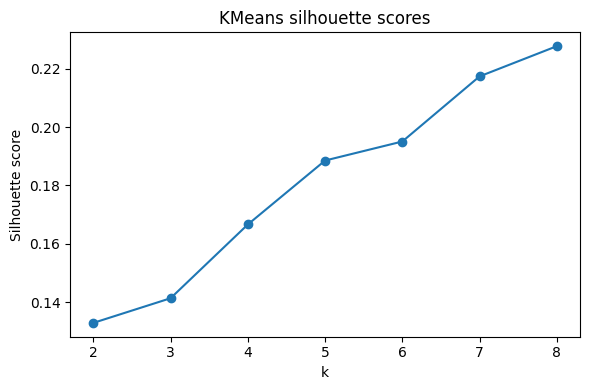

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("KMeans silhouette scores")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "kmeans_silhouette.png", dpi=150)

In [6]:
best_k = max(silhouette_scores, key=silhouette_scores.get)
best_k

8

## Fit clustering models

In [7]:
kmeans_model, kmeans_labels = fit_kmeans(X_scaled, best_k)
kmeans_purity = cluster_purity(y, kmeans_labels)
kmeans_silhouette = silhouette_scores[best_k]


gmm_model, gmm_labels = fit_gmm(X_scaled, best_k)
gmm_purity = cluster_purity(y, gmm_labels)


agg_model, agg_labels = fit_agglomerative(X_scaled, best_k)
agg_purity = cluster_purity(y, agg_labels)

In [8]:
cluster_summary = pd.DataFrame(
    {
        "metric": ["silhouette", "purity"],
        "kmeans": [kmeans_silhouette, kmeans_purity],
        "gmm": [None, gmm_purity],
        "agglomerative": [None, agg_purity],
    }
).set_index("metric")
cluster_summary

,kmeans,gmm,agglomerative
metric,,,
silhouette,0.227731,NaN,NaN
purity,0.894444,0.831944,0.897222


In [9]:
cluster_composition = pd.crosstab(y, kmeans_labels)
cluster_composition

col_0,0,1,2,3,4,5,6,7
language,,,,,,,,
German,0,44,89,0,1,0,0,46
Italian,0,1,0,0,90,89,0,0
Korean,0,90,0,0,30,0,60,0
Spanish,90,0,0,90,0,0,0,0


## Visualization

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'GMM clusters (PCA 2D)'}, xlabel='Component 1', ylabel='Component 2'>)

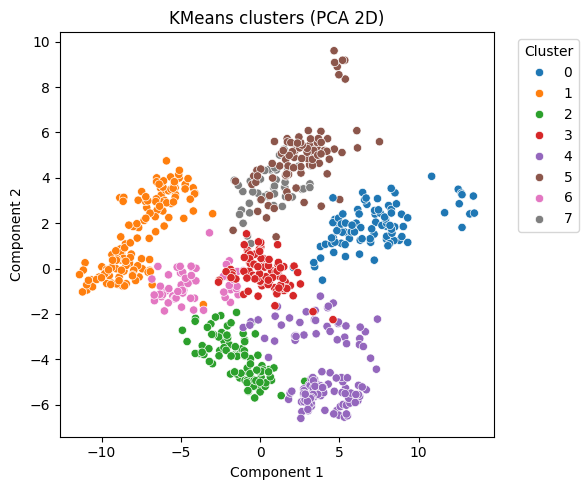

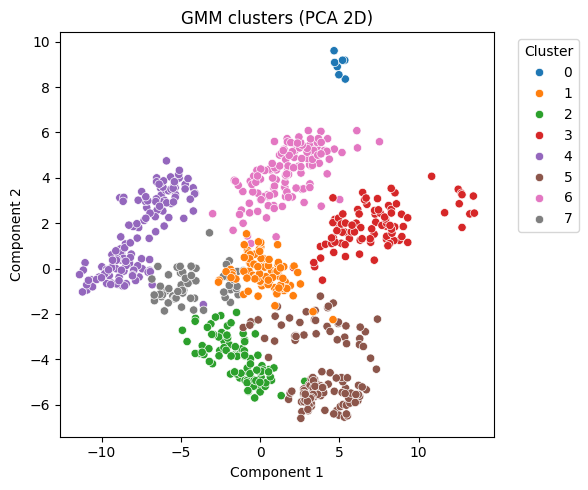

In [10]:
points_2d = reduce_to_2d(X_scaled, method="pca")
plot_clusters(
    points_2d,
    kmeans_labels,
    title="KMeans clusters (PCA 2D)",
    save_path=PROJECT_ROOT / "reports" / "figures" / "kmeans_clusters_pca.png",
)
plot_clusters(
    points_2d,
    gmm_labels,
    title="GMM clusters (PCA 2D)",
    save_path=PROJECT_ROOT / "reports" / "figures" / "gmm_clusters_pca.png",
)

In [11]:
use_tsne = False
if use_tsne:
    points_tsne = reduce_to_2d(X_scaled, method="tsne")
    plot_clusters(
        points_tsne,
        kmeans_labels,
        title="KMeans clusters (t-SNE 2D)",
        save_path=PROJECT_ROOT / "reports" / "figures" / "kmeans_clusters_tsne.png",
    )

In [12]:
clustering_metrics = {
    "best_k": int(best_k),
    "kmeans_silhouette": float(kmeans_silhouette),
    "kmeans_purity": float(kmeans_purity),
    "gmm_purity": float(gmm_purity),
    "agg_purity": float(agg_purity),
}

save_metrics(clustering_metrics, PROJECT_ROOT / "data" / "processed" / "clustering_metrics.json")